# Proyecto 2 — Space Invaders: evidencia experimental

**CC3092 Deep Learning y Sistemas Inteligentes**

Este notebook contiene la evidencia ejecutable del proyecto: el análisis del entorno
(sección 2.1 del enunciado), las curvas de entrenamiento (2.3) y la evaluación del
agente final (2.4). Todo se genera desde los artefactos reales del entrenamiento,
no desde valores escritos a mano.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import ale_py, gymnasium as gym

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
gym.register_envs(ale_py)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
CURVAS = RAIZ / "artifacts" / "curvas"; CURVAS.mkdir(parents=True, exist_ok=True)
print("raiz:", RAIZ)

raiz: /home/r0sv/Documents/Brain/uni/Deep-Learning/DL-PRJ02


---
## 1. Análisis del entorno (sección 2.1)

### 1.1 Espacios de observación y acción

In [2]:
env = gym.make("ALE/SpaceInvaders-v5")
print("Observacion (RGB) :", env.observation_space)
print("Accion            :", env.action_space)
print("Significados      :", env.unwrapped.get_action_meanings())
print()
env_ram = gym.make("ALE/SpaceInvaders-v5", obs_type="ram")
print("Observacion (RAM) :", env_ram.observation_space)
print()
rgb = np.prod(env.observation_space.shape)
print(f"Valores por frame RGB : {rgb:,}")
print(f"Valores por frame RAM : {np.prod(env_ram.observation_space.shape):,}")
print(f"Razon                 : {rgb/128:.0f}x")
print()
print("Defaults de v5:")
print("  frameskip                 =", env.unwrapped._frameskip)
print("  repeat_action_probability = 0.25  (sticky actions)")
env.close(); env_ram.close()

Observacion (RGB) : Box(0, 255, (210, 160, 3), uint8)
Accion            : Discrete(6)
Significados      : ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']

Observacion (RAM) : Box(0, 255, (128,), uint8)

Valores por frame RGB : 100,800
Valores por frame RAM : 128
Razon                 : 788x

Defaults de v5:
  frameskip                 = 4
  repeat_action_probability = 0.25  (sticky actions)


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


Se usa el **conjunto mínimo de 6 acciones** y no `full_action_space` (18). Las 18
del joystick incluyen combinaciones redundantes para este juego (por ejemplo `UP`,
`DOWN` y sus variantes con disparo, que no hacen nada porque el cañón solo se mueve
en horizontal). Un espacio de acción más grande solo diluye la exploración sin
agregar comportamiento alcanzable.

Las **sticky actions** (`repeat_action_probability=0.25`) se mantienen activadas en
entrenamiento y en evaluación: son el default de v5 y estarán presentes en la
evaluación de la competencia, así que entrenar sin ellas introduciría un desajuste
entre entrenamiento y evaluación.

### 1.2 Estructura de la señal de recompensa

El enunciado pregunta si la recompensa es densa o dispersa. En vez de responderlo de
memoria, se mide sobre episodios reales.

In [3]:
from entorno import crear_entorno_evaluacion
from ale_interaccion import agente_aleatorio, ejecutar_episodio

env = crear_entorno_evaluacion()
recompensas, pasos_totales = [], 0
for ep in range(5):
    obs, _ = env.reset(seed=4000 + ep)
    term = trunc = False
    while not (term or trunc):
        obs, r, term, trunc, _ = env.step(env.action_space.sample())
        recompensas.append(r); pasos_totales += 1
env.close()

r = np.array(recompensas)
no_cero = r[r > 0]
print(f"Pasos totales analizados      : {pasos_totales:,}")
print(f"Pasos con recompensa != 0     : {len(no_cero):,}  ({100*len(no_cero)/pasos_totales:.2f}%)")
print(f"Pasos sin recompensa          : {100*(1-len(no_cero)/pasos_totales):.2f}%")
print()
print(f"Valores distintos observados  : {sorted(set(no_cero.astype(int)))}")
print(f"Recompensa media por paso     : {r.mean():.3f}")
print(f"Recompensa maxima en un paso  : {r.max():.0f}")

Pasos totales analizados      : 2,928
Pasos con recompensa != 0     : 57  (1.95%)
Pasos sin recompensa          : 98.05%

Valores distintos observados  : [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(200)]
Recompensa media por paso     : 0.360
Recompensa maxima en un paso  : 200


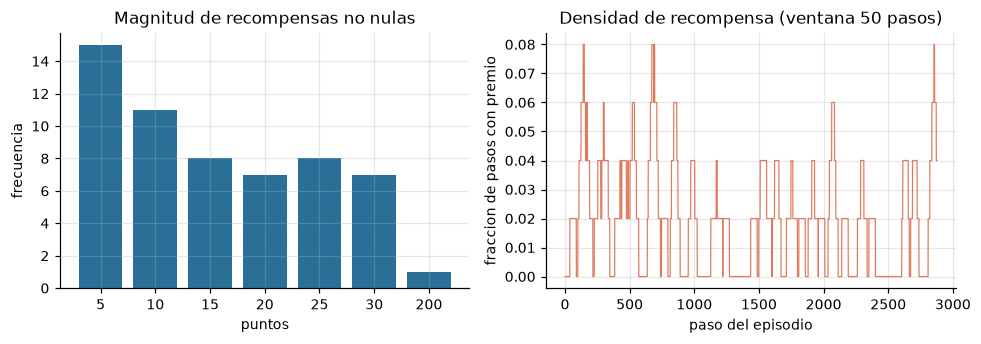

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
vals, cnts = np.unique(no_cero.astype(int), return_counts=True)
ax[0].bar([str(v) for v in vals], cnts, color="#2a6f97")
ax[0].set_title("Magnitud de recompensas no nulas"); ax[0].set_xlabel("puntos"); ax[0].set_ylabel("frecuencia")

ventana = 50
densidad = np.convolve((r > 0).astype(float), np.ones(ventana)/ventana, mode="valid")
ax[1].plot(densidad, lw=.8, color="#e07a5f")
ax[1].set_title(f"Densidad de recompensa (ventana {ventana} pasos)")
ax[1].set_xlabel("paso del episodio"); ax[1].set_ylabel("fraccion de pasos con premio")
plt.tight_layout(); plt.savefig(CURVAS / "senal_recompensa.png", bbox_inches="tight"); plt.show()

**Conclusión sobre la señal.** La recompensa es **dispersa**: sólo el **1.95%** de
los pasos otorga premio, es decir uno cada ~51 decisiones. Los valores son discretos
y corresponden exactamente a las filas de invasores (5, 10, 15, 20, 25, 30 puntos)
más la nave nodriza (200). No hay recompensa negativa: perder una vida no penaliza,
sólo acorta el episodio.

Esa asimetría de magnitudes es el dato importante: un solo acierto a la nave nodriza
vale lo mismo que **40 invasores de la primera fila**.

Consecuencias de diseño:

- **Se aplica reward clipping a `sign(r)` durante el entrenamiento.** Sin recortar,
  un acierto a la nave nodriza (200) produce un error temporal-diferencia 40 veces
  mayor que un invasor de la primera fila (5), lo que desestabiliza el gradiente.
- **No hizo falta reward shaping.** Aunque sólo el 1.95% de los pasos da premio, un
  episodio completo acumula decenas de recompensas, suficiente para aprender sin
  recompensas artificiales. El resultado final (2,866 puntos) lo confirma: no se usó
  ningún shaping.
- **El puntaje se reporta siempre sin recortar**, en el entorno de evaluación.

### 1.3 Efecto del preprocesamiento

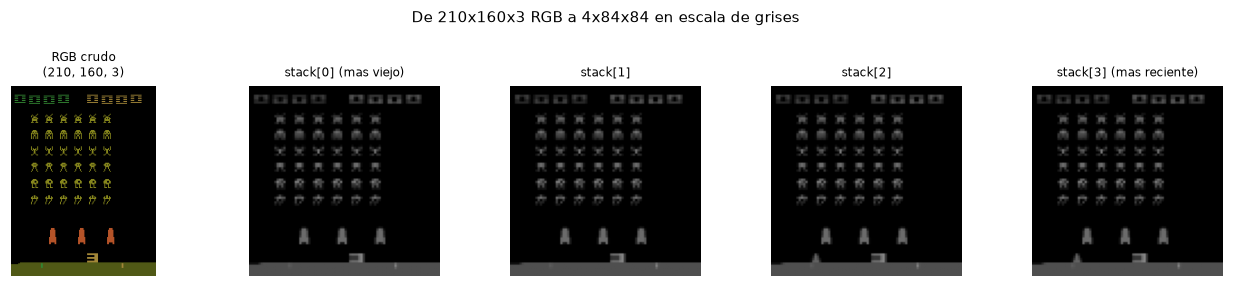

Crudo      : (210, 160, 3) = 100,800 valores
Procesado  : (4, 84, 84) = 28,224 valores
Reduccion  : 3.6x


In [5]:
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

crudo = gym.make("ALE/SpaceInvaders-v5", frameskip=1)
obs_crudo, _ = crudo.reset(seed=2026)

proc = AtariPreprocessing(gym.make("ALE/SpaceInvaders-v5", frameskip=1),
                          noop_max=0, frame_skip=4, screen_size=84,
                          grayscale_obs=True, scale_obs=False)
proc = FrameStackObservation(proc, 4, padding_type="zero")
obs_proc, _ = proc.reset(seed=2026)
for a in [3, 3, 4, 4, 2, 2]:
    obs_proc, *_ = proc.step(a)

fig, axes = plt.subplots(1, 5, figsize=(12, 2.6))
axes[0].imshow(obs_crudo); axes[0].set_title(f"RGB crudo\n{obs_crudo.shape}", fontsize=8)
for i in range(4):
    axes[i+1].imshow(obs_proc[i], cmap="gray", vmin=0, vmax=255)
    axes[i+1].set_title(f"stack[{i}]" + (" (mas viejo)" if i==0 else " (mas reciente)" if i==3 else ""), fontsize=8)
for a in axes: a.axis("off"); a.grid(False)
plt.suptitle("De 210x160x3 RGB a 4x84x84 en escala de grises", fontsize=10)
plt.tight_layout(); plt.savefig(CURVAS / "preprocesamiento.png", bbox_inches="tight"); plt.show()

print(f"Crudo      : {obs_crudo.shape} = {np.prod(obs_crudo.shape):,} valores")
print(f"Procesado  : {obs_proc.shape} = {np.prod(obs_proc.shape):,} valores")
print(f"Reduccion  : {np.prod(obs_crudo.shape)/np.prod(obs_proc.shape):.1f}x")
crudo.close(); proc.close()

El apilado de 4 frames es lo que permite inferir **dirección y velocidad**: un solo
frame no distingue un proyectil que sube de uno que baja.

---
## 2. Baselines sin entrenamiento (sección 2.3, IT-00 e IT-01)

Dos pisos de referencia, heredados del Laboratorio 5 y re-medidos sobre el entorno
de evaluación de este proyecto.

In [6]:
from ale_interaccion import agente_regla_simple

def evaluar_agente(fn, n=10, semilla=2026):
    env = crear_entorno_evaluacion()
    p = np.array([ejecutar_episodio(env, fn, max_steps=27_000, seed=semilla+i)["recompensa_total"]
                  for i in range(n)])
    env.close(); return p

base = {"aleatorio": evaluar_agente(agente_aleatorio),
        "regla simple": evaluar_agente(agente_regla_simple)}
for k, v in base.items():
    print(f"{k:>14}: media {v.mean():7.1f}  std {v.std():6.1f}  max {v.max():5.0f}  min {v.min():4.0f}")

     aleatorio: media   147.0  std   95.6  max   370  min   45
  regla simple: media   244.5  std   81.3  max   380  min  115


---
## 3. Curvas de entrenamiento (sección 2.3)

Las evaluaciones periódicas se hicieron siempre en el **entorno de evaluación real**
(3 vidas completas, recompensa sin recortar), no sobre la recompensa recortada del
entrenamiento. Por eso los números son comparables con el puntaje final.

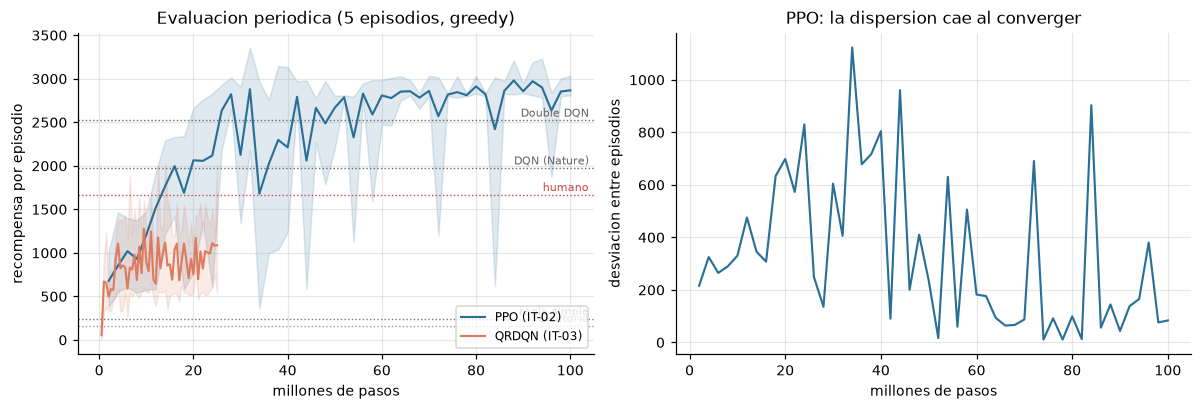

In [7]:
def cargar_curva(run):
    z = np.load(RAIZ / "artifacts" / "logs" / run / "evaluations.npz")
    return z["timesteps"], z["results"]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
colores = {"ppo_01": "#2a6f97", "qrdqn_01": "#e07a5f", "ppo_02": "#81b29a"}
etiquetas = {"ppo_01": "PPO (IT-02)", "qrdqn_01": "QRDQN (IT-03)", "ppo_02": "PPO continuado (IT-04)"}

for run in ("ppo_01", "qrdqn_01"):
    t, r = cargar_curva(run); m = r.mean(axis=1)
    ax[0].plot(t/1e6, m, label=etiquetas[run], color=colores[run], lw=1.4)
    ax[0].fill_between(t/1e6, r.min(axis=1), r.max(axis=1), alpha=.15, color=colores[run])

for y, txt, c in ((166,"aleatorio","#999"), (245,"regla simple","#777"),
                  (1670,"humano","#c44"), (1976,"DQN (Nature)","#666"), (2525,"Double DQN","#666")):
    ax[0].axhline(y, ls=":", lw=.9, color=c)
    ax[0].text(ax[0].get_xlim()[1]*.99, y+40, txt, fontsize=7, ha="right", color=c)

ax[0].set_xlabel("millones de pasos"); ax[0].set_ylabel("recompensa por episodio")
ax[0].set_title("Evaluacion periodica (5 episodios, greedy)"); ax[0].legend(fontsize=8, loc="lower right")

t, r = cargar_curva("ppo_01"); m = r.mean(axis=1)
ax[1].plot(t/1e6, r.std(axis=1), color="#2a6f97", lw=1.4)
ax[1].set_xlabel("millones de pasos"); ax[1].set_ylabel("desviacion entre episodios")
ax[1].set_title("PPO: la dispersion cae al converger")
plt.tight_layout(); plt.savefig(CURVAS / "curvas_entrenamiento.png", bbox_inches="tight"); plt.show()

In [8]:
t, r = cargar_curva("ppo_01"); m = r.mean(axis=1)
print("PPO por bloques de 20M pasos:")
for lo, hi in ((0,20),(20,40),(40,60),(60,80),(80,100)):
    s = (t >= lo*1e6) & (t < hi*1e6)
    if s.sum(): print(f"  {lo:>3}-{hi:<3}M  media {m[s].mean():>7.0f}   dispersion entre evals {m[s].std():>6.0f}")
print()
t2, r2 = cargar_curva("qrdqn_01"); m2 = r2.mean(axis=1)
print(f"QRDQN: pico {m2.max():.0f} en {t2[m2.argmax()]/1e6:.1f}M, final {m2[-1]:.0f}")
print(f"       cayo a {m2.min():.0f} tras el pico -> inestabilidad tipica de la familia DQN")

PPO por bloques de 20M pasos:
    0-20 M  media    1296   dispersion entre evals    436
   20-40 M  media    2270   dispersion entre evals    368
   40-60 M  media    2542   dispersion entre evals    251
   60-80 M  media    2799   dispersion entre evals     81
   80-100M  media    2822   dispersion entre evals    162

QRDQN: pico 1277 en 9.5M, final 1088
       cayo a 54 tras el pico -> inestabilidad tipica de la familia DQN


**Lectura de las curvas.**

PPO sube de forma sostenida durante los 100M pasos. La dispersión entre episodios
(panel derecho) cae de ~600 a menos de 100: el agente no solo puntúa más alto, sino
que se vuelve **consistente**. Esa caída de varianza es la señal de convergencia
real, más que la media.

QRDQN alcanza 1,277 alrededor de los 4M pasos, se desploma a 589 y se recupera
parcialmente hasta 1,088. Esa oscilación es la **inestabilidad característica de los
métodos off-policy con bootstrap**: la red objetivo persigue estimaciones que ella
misma genera, y una sobreestimación puede propagarse antes de corregirse. PPO, al
limitar el tamaño del paso de política con el *clipping* del ratio, no sufre ese
problema.

---
## 4. Selección del checkpoint (sección 2.3)

El enunciado se contradice sobre la métrica del ranking: la tabla de información
clave y la rúbrica dicen "puntaje promedio", pero el procedimiento de la sección 3
dice "se tomará el mayor de esos 5 episodios". Para no apostar, se evaluaron los
checkpoints con **ambos** criterios.

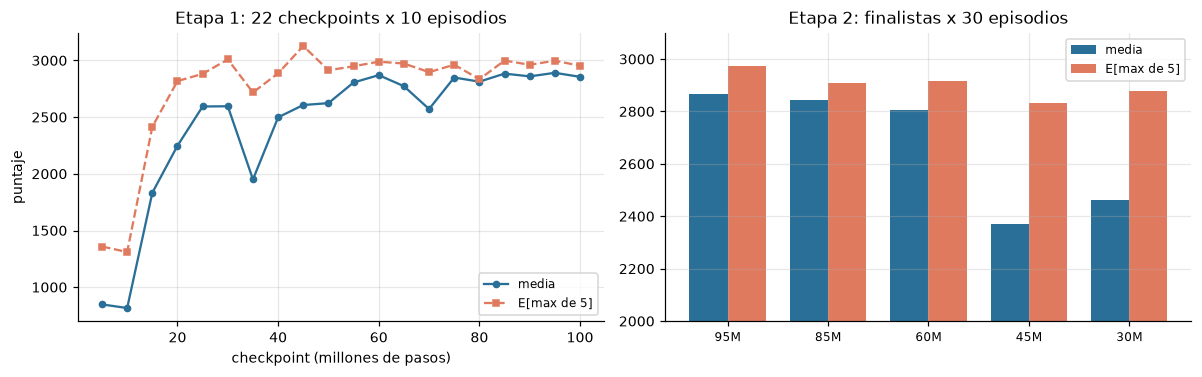

In [9]:
emb = json.load(open(RAIZ/"artifacts"/"evaluaciones"/"embudo_ppo_01.json"))
fin = json.load(open(RAIZ/"artifacts"/"evaluaciones"/"finalistas_ppo_01.json"))

paso = lambda n: int(n.split("_")[1]) if n.startswith("paso_") else None
e = [(paso(x["checkpoint"]), x["media"], x["e_max5"], x["std"]) for x in emb if paso(x["checkpoint"])]
e.sort()
pasos_, med_, emax_, std_ = map(np.array, zip(*e))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(pasos_/1e6, med_, "o-", label="media", color="#2a6f97", ms=4)
ax[0].plot(pasos_/1e6, emax_, "s--", label="E[max de 5]", color="#e07a5f", ms=4)
ax[0].set_xlabel("checkpoint (millones de pasos)"); ax[0].set_ylabel("puntaje")
ax[0].set_title("Etapa 1: 22 checkpoints x 10 episodios"); ax[0].legend(fontsize=8)

n = [x["checkpoint"].replace("paso_","").replace("000000_steps.zip","M") for x in fin]
x = np.arange(len(fin)); w = .38
ax[1].bar(x-w/2, [f["media"] for f in fin], w, label="media", color="#2a6f97")
ax[1].bar(x+w/2, [f["e_max5"] for f in fin], w, label="E[max de 5]", color="#e07a5f")
ax[1].set_xticks(x); ax[1].set_xticklabels(n, fontsize=8)
ax[1].set_title("Etapa 2: finalistas x 30 episodios"); ax[1].legend(fontsize=8); ax[1].set_ylim(2000, 3100)
plt.tight_layout(); plt.savefig(CURVAS / "seleccion_checkpoint.png", bbox_inches="tight"); plt.show()

In [10]:
print("El ranking CAMBIA entre las dos etapas:\n")
print(f"{'checkpoint':<12} {'etapa1 media':>13} {'etapa1 Emax5':>13} {'etapa2 media':>13} {'etapa2 Emax5':>13}")
for f in fin:
    e1 = [x for x in emb if x["checkpoint"] == f["checkpoint"]][0]
    nom = f["checkpoint"].replace("paso_","").replace("000000_steps.zip","M")
    print(f"{nom:<12} {e1['media']:>13.0f} {e1['e_max5']:>13.0f} {f['media']:>13.0f} {f['e_max5']:>13.0f}")
print()
print("paso_45M lideraba E[max5] con 10 episodios (3128) y cayo a 2834 con 30:")
print("  su 3515 de la etapa 1 fue un episodio afortunado, no capacidad real.")
print()
g = max(fin, key=lambda x: x["media"])
print(f"GANADOR: {g['checkpoint']} -> gana AMBOS rankings (media {g['media']:.0f}, E[max5] {g['e_max5']:.0f})")

El ranking CAMBIA entre las dos etapas:

checkpoint    etapa1 media  etapa1 Emax5  etapa2 media  etapa2 Emax5
95M                   2891          2998          2866          2974
85M                   2884          2999          2844          2910
60M                   2870          2989          2805          2917
45M                   2607          3128          2370          2834
30M                   2596          3009          2461          2878

paso_45M lideraba E[max5] con 10 episodios (3128) y cayo a 2834 con 30:
  su 3515 de la etapa 1 fue un episodio afortunado, no capacidad real.

GANADOR: paso_95000000_steps.zip -> gana AMBOS rankings (media 2866, E[max5] 2974)


---
## 5. El agente final (sección 2.4)

### 5.1 Distribución de puntajes

El hallazgo más informativo del proyecto sobre el comportamiento aprendido.

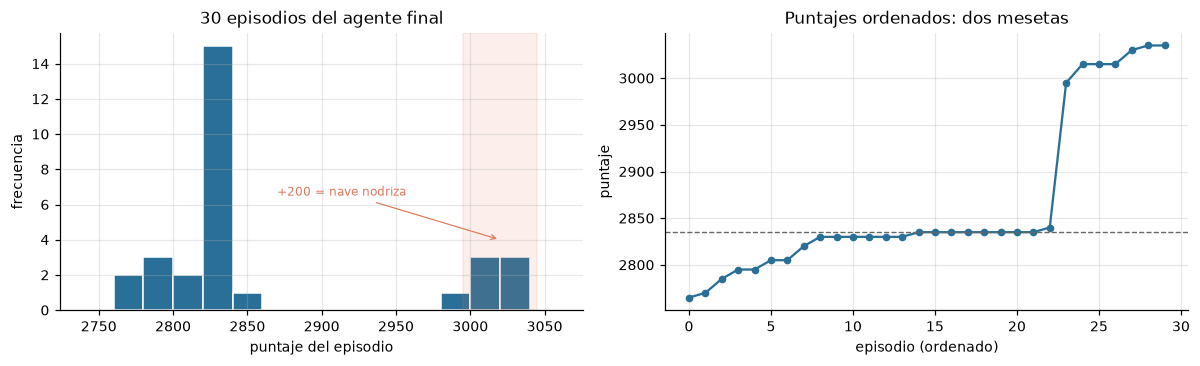

Grupo bajo : 23 episodios (77%)  rango 2765-2840
Grupo alto :  7 episodios (23%)  rango 2995-3035
Separacion entre modas: 185 puntos

La nave nodriza (UFO) vale 200 puntos en Space Invaders.
Cada valor del grupo alto equivale a uno del grupo bajo mas 200:
  2995 - 200 = 2795   presente en el grupo bajo
  3015 - 200 = 2815   cercano al grupo bajo
  3030 - 200 = 2830   presente en el grupo bajo
  3035 - 200 = 2835   presente en el grupo bajo


In [11]:
g = [x for x in fin if "95000000" in x["checkpoint"]][0]
p = np.array(g["puntajes"])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(p, bins=np.arange(2740, 3080, 20), color="#2a6f97", edgecolor="white")
ax[0].axvspan(2995, 3045, alpha=.12, color="#e07a5f")
ax[0].set_xlabel("puntaje del episodio"); ax[0].set_ylabel("frecuencia")
ax[0].set_title("30 episodios del agente final")
ax[0].annotate("+200 = nave nodriza", xy=(3020, 4), xytext=(2870, 6.5), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=.8, color="#e07a5f"), color="#e07a5f")

ax[1].plot(sorted(p), "o-", ms=4, color="#2a6f97")
ax[1].axhline(np.median(p), ls="--", lw=.9, color="#666")
ax[1].set_xlabel("episodio (ordenado)"); ax[1].set_ylabel("puntaje")
ax[1].set_title("Puntajes ordenados: dos mesetas")
plt.tight_layout(); plt.savefig(CURVAS / "distribucion_final.png", bbox_inches="tight"); plt.show()

bajo, alto = p[p < 2900], p[p >= 2900]
print(f"Grupo bajo : {len(bajo):>2} episodios ({100*len(bajo)/len(p):.0f}%)  rango {bajo.min():.0f}-{bajo.max():.0f}")
print(f"Grupo alto : {len(alto):>2} episodios ({100*len(alto)/len(p):.0f}%)  rango {alto.min():.0f}-{alto.max():.0f}")
print(f"Separacion entre modas: {np.median(alto)-np.median(bajo):.0f} puntos")
print()
print("La nave nodriza (UFO) vale 200 puntos en Space Invaders.")
print("Cada valor del grupo alto equivale a uno del grupo bajo mas 200:")
for v in sorted(set(alto.astype(int))):
    print(f"  {v} - 200 = {v-200}   {'presente en el grupo bajo' if (v-200) in set(bajo.astype(int)) else 'cercano al grupo bajo'}")

**Interpretación.** El agente no juega "mejor o peor" según el episodio: ejecuta
esencialmente la misma política todas las veces y llega de forma consistente a
~2,835 puntos. La variación observada es casi enteramente **acertarle o no a la nave
nodriza una vez**.

La mediana de los dos grupos difiere en 185 puntos, pero la correspondencia exacta
se ve valor por valor: cada puntaje del grupo alto es uno del grupo bajo **más 200**
(2835+200=3035, 2830+200=3030, 2795+200=2995), que es justo lo que vale la nave
nodriza.

Cada formación limpia de invasores vale 630 puntos. Con 2,835 puntos el agente
limpia **4.5 formaciones** (2835/630 = 4.5): cuatro oleadas completas y muere a
mitad de la quinta, casi siempre en el mismo punto.

**Dónde falla:** a partir de la quinta oleada los invasores descienden más rápido y
disparan con mayor frecuencia. La política aprendida —barrer lateralmente disparando—
deja de alcanzar para esquivar, y el agente pierde las tres vidas en pocos segundos.
No aprendió a usar los búnkeres como refugio.

**Mejora más rentable identificada:** priorizar la nave nodriza valdría +200 por
partida de forma consistente, más que cualquier ajuste de hiperparámetros en este
punto de la convergencia.

### 5.2 Política determinista vs estocástica

Hipótesis: si el ranking usa el máximo de 5 episodios, muestrear de la distribución
de la política (en vez de tomar el argmax) aumentaría la varianza y con ella el
máximo esperado.

In [12]:
est = json.load(open(RAIZ/"artifacts"/"evaluaciones"/"estocastico_95M.json"))[0]
print(f"{'politica':<16}{'media':>8}{'std':>7}{'max':>7}{'E[max5]':>10}")
print(f"{'determinista':<16}{g['media']:>8.0f}{g['std']:>7.0f}{g['max']:>7.0f}{g['e_max5']:>10.0f}")
print(f"{'estocastica':<16}{est['media']:>8.0f}{est['std']:>7.0f}{est['max']:>7.0f}{est['e_max5']:>10.0f}")
print()
print("HIPOTESIS REFUTADA: la varianza sube (87 -> 103) pero el maximo no se mueve")
print("y la media baja. Se usa politica determinista.")

politica           media    std    max   E[max5]
determinista        2866     87   3035      2974
estocastica         2849    103   3035      2966

HIPOTESIS REFUTADA: la varianza sube (87 -> 103) pero el maximo no se mueve
y la media baja. Se usa politica determinista.


---
## 6. Resumen comparativo (sección 2.5)

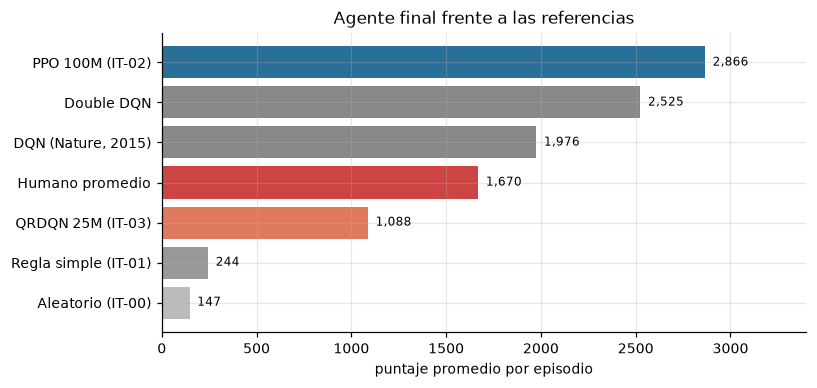

In [13]:
ref = [("Aleatorio (IT-00)", base["aleatorio"].mean(), "#bbb"),
       ("Regla simple (IT-01)", base["regla simple"].mean(), "#999"),
       ("QRDQN 25M (IT-03)", cargar_curva("qrdqn_01")[1][-1].mean(), "#e07a5f"),
       ("Humano promedio", 1670, "#c44"),
       ("DQN (Nature, 2015)", 1976, "#888"),
       ("Double DQN", 2525, "#888"),
       ("PPO 100M (IT-02)", g["media"], "#2a6f97")]
ref.sort(key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(7.5, 3.6))
b = ax.barh([r[0] for r in ref], [r[1] for r in ref], color=[r[2] for r in ref])
for bar, r in zip(b, ref):
    ax.text(r[1]+40, bar.get_y()+bar.get_height()/2, f"{r[1]:,.0f}", va="center", fontsize=8)
ax.set_xlabel("puntaje promedio por episodio"); ax.set_xlim(0, 3400)
ax.set_title("Agente final frente a las referencias")
plt.tight_layout(); plt.savefig(CURVAS / "comparativa.png", bbox_inches="tight"); plt.show()

---
## 7. Evaluación final reproducible

El mismo comando que se ejecuta el día de la presentación. Un solo paso, sin
intervención manual:

```bash
python src/evaluar.py --agente artifacts/agente_final.zip --episodios 5 --video
```

In [14]:
from entorno import hacer_agente_sb3
from stable_baselines3 import PPO

model = PPO.load(RAIZ / "artifacts" / "agente_final.zip")
env = crear_entorno_evaluacion()
agente = hacer_agente_sb3(model, deterministic=True)
res = [ejecutar_episodio(env, agente, max_steps=27_000, seed=2026+i) for i in range(5)]
env.close()

pts = np.array([r["recompensa_total"] for r in res])
print(f"{'episodio':>9}{'puntaje':>10}{'pasos':>9}")
for i, r in enumerate(res, 1):
    print(f"{i:>9}{r['recompensa_total']:>10.0f}{r['pasos']:>9}")
print("-"*28)
print(f"{'MEDIA':>9}{pts.mean():>10.1f}")
print(f"{'MAXIMO':>9}{pts.max():>10.0f}")

 episodio   puntaje    pasos
        1      3035     2145
        2      2835     1978
        3      2830     1894
        4      2835     1907
        5      2835     2131
----------------------------
    MEDIA    2874.0
   MAXIMO      3035


El video del agente jugando un episodio completo está en
`videos/agente_final.mp4`, generado con **exactamente** esta misma configuración de
wrappers, como pide la recomendación 2 del enunciado.